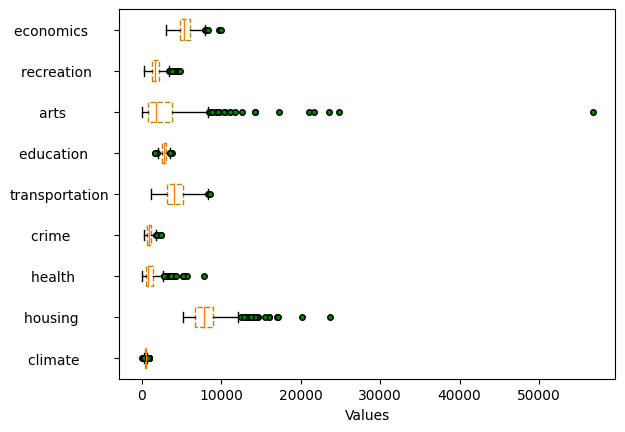

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 定義文件路徑
file_paths = {
    'ALL': r'C:\Users\jameslin\Documents\python\淺度機器學習\city_quality.xlsx',
}
df = pd.read_excel(file_paths['ALL'])
ratings = np.array(df)
categories = df.columns
fig, ax = plt.subplots()
boxprops = dict(linestyle = '--', linewidth = 1, \
color = 'darkgoldenrod')
flierprops = dict(marker='o', markerfacecolor = 'green',
markersize = 4, linestyle = 'none')
ax.boxplot(ratings, boxprops = boxprops, \
flierprops = flierprops, \
labels = categories, vert = False)
ax.set_xlabel('Values')
plt.show()


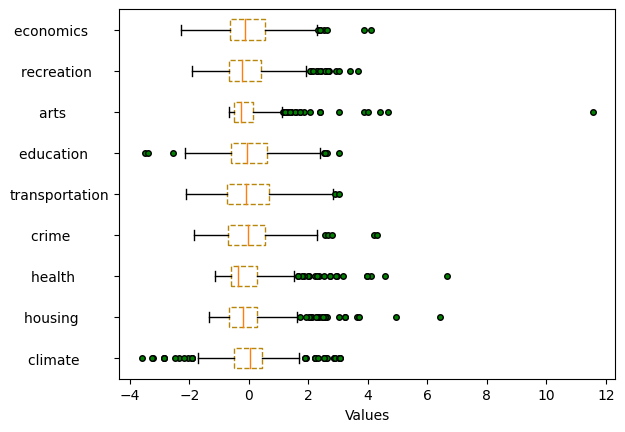

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Compute the mean and std to be used for later scaling.
scaler.fit(ratings)
# Apply transform to dataset.
ratings_ = scaler.transform(ratings)
categories = df.columns
fig, ax = plt.subplots()
boxprops = dict(linestyle = '--', linewidth = 1, \
color = 'darkgoldenrod')
flierprops = dict(marker='o', markerfacecolor = 'green',
markersize = 4, linestyle = 'none')
ax.boxplot(ratings_, boxprops = boxprops, \
flierprops = flierprops, \
labels = categories, vert = False)
ax.set_xlabel('Values')
plt.show()

<AxesSubplot: >

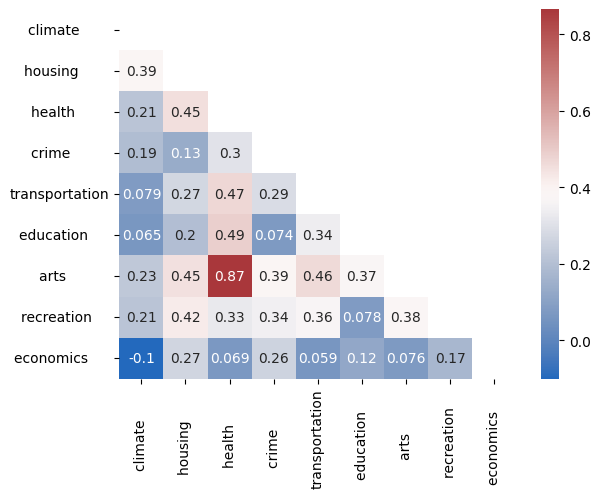

In [10]:
# 相關係數矩陣
import seaborn
import pandas as pd
df = pd.DataFrame(ratings_, columns = categories)
R = df.corr()
mask = np.triu(np.ones_like(R, dtype=bool)) # diagonal mask
seaborn.heatmap(R, annot=True, mask = mask, cmap='vlag')


In [11]:
# ratings_ is a 329 by 9 data matrix
Sx = np.cov(ratings_.T, bias=False)
N = ratings_.shape[0]
mu_x = ratings_.mean(axis = 0)
Tmp = ratings_ - mu_x
# Tmp = ratings_ − np.tile(mu_x, (N, 1))
Sx_formula = Tmp.T @ Tmp / (N - 1)

In [12]:
from numpy.linalg import eig
w, v = eig(Sx_formula)
idx = np.argsort(-w) #sort eigenvalues in descending order
# idx = np.argsort(w)[::−1]
eigvals = w[idx]
eigvecs = v[:, idx]
Sigma_x = eigvecs @ np.diag(eigvals) @ eigvecs.T


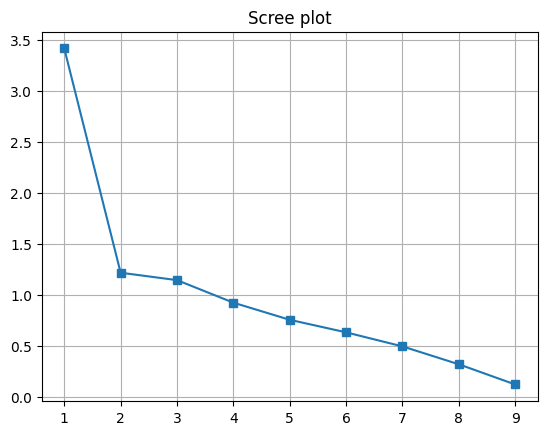

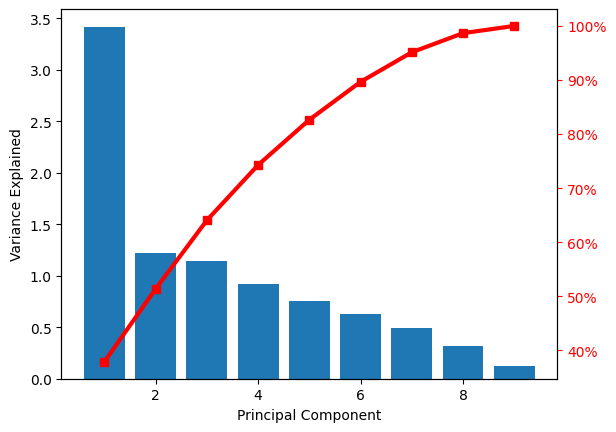

In [13]:
from matplotlib.ticker import PercentFormatter
plt.figure()
x = np.arange(1, 1+len(eigvals))
plt.plot(x, eigvals, marker='s')
plt.title('Scree plot')
plt.grid(True)
plt.show()
fig, ax = plt.subplots()
x = np.arange(1, 1+len(eigvals))
ax.bar(x, eigvals)
ax2 = ax.twinx()
ax2.plot(x, eigvals.cumsum()/eigvals.sum()*100, \
marker='s', color='red', lw=3)
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
x1 = np.array([1, 2, 3, 4, 5])
x2 = np.array([2, 1, 4, 5, 4])
X = np.c_[x1, x2] # 資料矩陣
# pca = PCA(n_components=1).fit(X) # 取 第 一 個 特 徵 向 量
pca = PCA().fit(X) # 進 行 主 成 分 分 析
print(pca.explained_variance_ratio_) # 共 變 異 矩 陣 特 徵 值 佔 比
print(pca.explained_variance_) # 共 變 異 矩 陣 的 特 徵 值
print(pca.components_) # 共 變 異 矩 陣 的 特 徵 向 量
eigvals = pca.explained_variance_
eigvecs = pca.components_.T # by column [v1 v2]


[0.88509585 0.11490415]
[4.60249844 0.59750156]
[[-0.68922507 -0.72454731]
 [ 0.72454731 -0.68922507]]
